# model charts: walk-forward, how good it is, what drives it, and the $300M backtest

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

sys.path.append("../src")
from backtest import band_averages, profit_and_risk

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#a3a29c"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})


def money(x, _=None):
    for size, unit in [(1e9, "B"), (1e6, "M"), (1e3, "k")]:
        if abs(x) >= size:
            return f"${x / size:g}{unit}"
    return f"${x:g}"


PCT = PercentFormatter(1.0, decimals=0)


def save(fig, name):
    fig.savefig(f"../figures/{name}.png")


def dots(ax, labels, series, title):
    # horizontal dot plot. series is a list of (values, color, name)
    y = np.arange(len(labels))
    for values, color, name in series:
        ax.scatter(values, y, color=color, s=34, label=name, zorder=3)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)


def legend_below(ax):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=8.5)

In [2]:
d = pd.read_csv("../data/processed/movies_clean.csv")
pred = pd.read_csv("../data/processed/predictions_cast.csv")
folds = pd.read_csv("../data/processed/fold_metrics_cast.csv")
importance = pd.read_csv("../data/processed/feature_importance_cast.csv", index_col=0)["mean_abs_shap"]
draws = pd.read_csv("../data/processed/backtest_draws.csv")
picks = pd.read_csv("../data/processed/backtest_model_picks.csv")
picks = picks[picks["penalty"] == 0.25]  # the risk-adjusted slate i went with

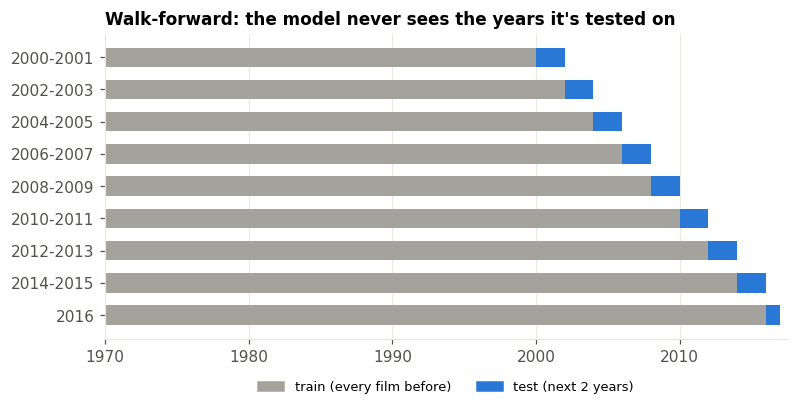

In [3]:
# walk-forward: each row is one fold. train on everything before, test on the next 2 years
fig, ax = plt.subplots(figsize=(8, 3.6))
starts = list(range(2000, 2017, 2))
for row, start in enumerate(starts):
    end = min(start + 1, 2016)
    ax.barh(row, start - 1970, left=1970, color=GRAY, height=0.6)
    ax.barh(row, end - start + 1, left=start, color=BLUE, height=0.6)
ax.set_yticks(range(len(starts)), folds["years"])
ax.invert_yaxis()
ax.set_xlim(1970, 2017.5)
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=GRAY, label="train (every film before)"), Patch(color=BLUE, label="test (next 2 years)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8.5)
ax.set_title("Walk-forward: the model never sees the years it's tested on")
save(fig, "11_walk_forward")

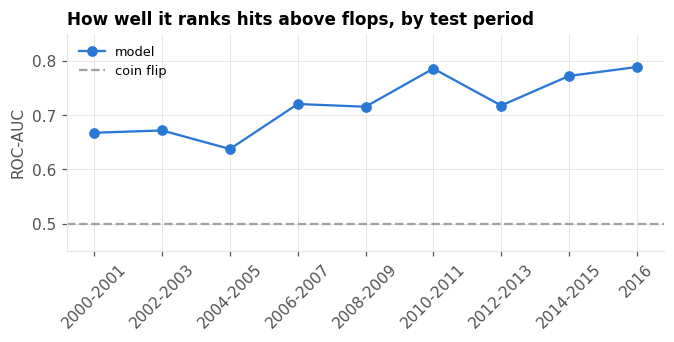

In [4]:
# success pr-auc per test period. the baseline is each period's share of films that made their budget back
from sklearn.metrics import average_precision_score
fold_of = lambda y: "2016" if y == 2016 else f"{y // 2 * 2}-{y // 2 * 2 + 1}"
by_fold = pred.groupby(pred["year"].astype(int).map(fold_of))
pr = by_fold.apply(lambda f: average_precision_score(f["profitable"], f["pred"])).reindex(folds["years"])
share = by_fold["profitable"].mean().reindex(folds["years"])

fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(folds))
ax.plot(x, pr, color=BLUE, marker="o", label="model")
ax.plot(x, share, color=GRAY, linestyle="--", marker="o", markersize=3, label="random pick (share of hits)")
ax.set_xticks(x, folds["years"], rotation=45)
ax.set_ylim(0.5, 1)
ax.set_ylabel("success PR-AUC")
ax.legend(loc="lower right", fontsize=8.5)
ax.set_title("How well it picks out hits, by test period")
fig.subplots_adjust(bottom=0.3)
save(fig, "12_auc_by_fold")
print(pd.DataFrame({"pr_auc": pr, "share": share}).round(3))


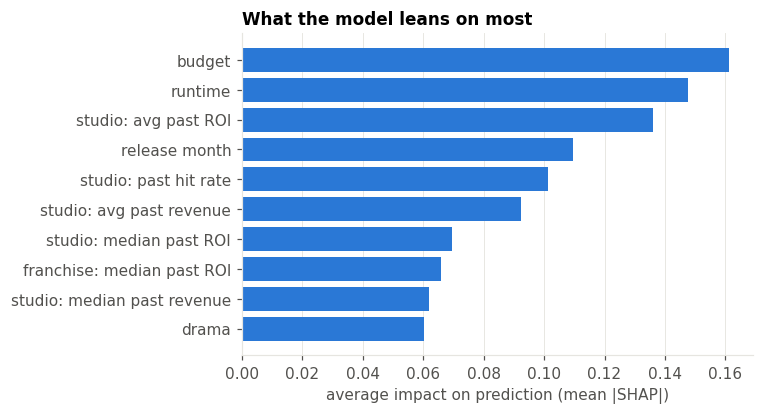

In [5]:
labels = {
    "log_budget": "budget", "runtime": "runtime", "month": "release month", "year": "year",
    "studio_mean_roi": "studio: avg past ROI", "studio_hit_rate": "studio: past hit rate",
    "studio_median_revenue": "studio: median past revenue", "studio_mean_revenue": "studio: avg past revenue",
    "studio_median_roi": "studio: median past ROI", "studio_n_prior": "studio: # past films",
    "franchise_median_roi": "franchise: median past ROI", "cast_n_prior": "cast: # past films",
    "cast_median_roi": "cast: median past ROI", "cast_mean_revenue": "cast: avg past revenue",
    "genre_drama": "drama", "is_independent": "independent",
}
top = importance.head(10)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh([labels.get(f, f) for f in top.index], top.values, color=BLUE)
ax.grid(axis="y", visible=False)
ax.set_xlabel("average impact on prediction (mean |SHAP|)")
ax.set_title("What the model leans on most")
save(fig, "13_shap_top")

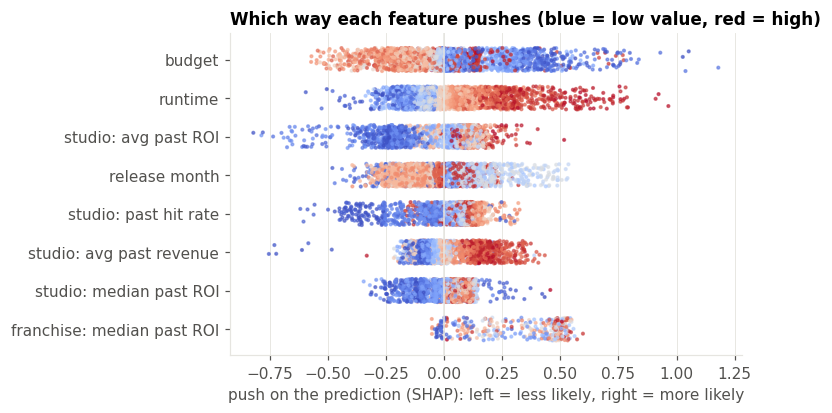

In [6]:
# which way each top feature pushes: one dot per film. right = more likely to make its budget back
shap = pd.read_csv("../data/processed/shap_cast.csv")
values = pred.set_index("id").loc[shap["id"]]
top = importance.head(8).index
fig, ax = plt.subplots(figsize=(6, 3.8))
rng = np.random.default_rng(0)
for row, f in enumerate(top[::-1]):
    v = values[f].rank(pct=True).values  # colour = how high the film's value is compared with other films
    ax.scatter(shap[f], row + rng.uniform(-0.3, 0.3, len(shap)), c=v, cmap="coolwarm", s=3, alpha=0.6,
               vmin=0, vmax=1, rasterized=True)
ax.set_yticks(range(len(top)), [labels.get(f, f) for f in top[::-1]])
ax.axvline(0, color=GRID, linewidth=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("push on the prediction (SHAP): left = less likely, right = more likely")
ax.set_title("Which way each feature pushes (blue = low value, red = high)")
save(fig, "13b_shap_direction")

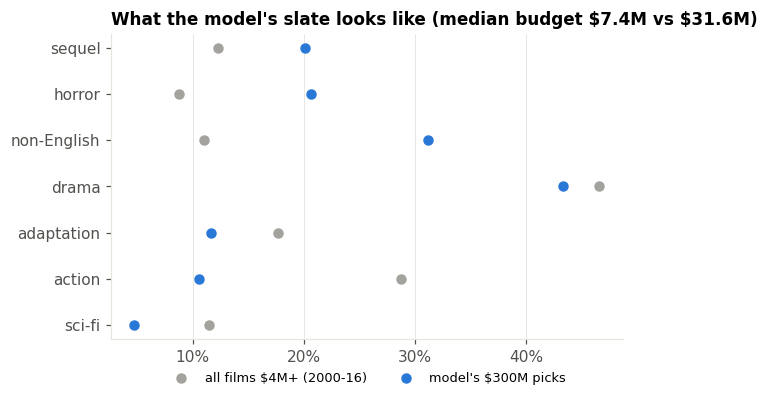

In [7]:
pool = pred
traits = {"sequel": "is_sequel", "horror": "genre_horror", "non-English": None, "drama": "genre_drama",
          "adaptation": "is_adaptation", "action": "genre_action", "sci-fi": "genre_science_fiction"}

def share(films, col):
    return 1 - films["is_english"].mean() if col is None else films[col].mean()

names = list(traits)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.6))
dots(ax, names, [([share(pool, traits[n]) for n in names], GRAY, "all films $4M+ (2000-16)"),
                 ([share(picks, traits[n]) for n in names], BLUE, "model's $300M picks")],
     f"What the model's slate looks like (median budget \${picks['budget_real'].median() / 1e6:.1f}M "
     f"vs \${pool['budget_real'].median() / 1e6:.1f}M)")
ax.xaxis.set_major_formatter(PCT)
legend_below(ax)
save(fig, "14_picks_vs_pool")

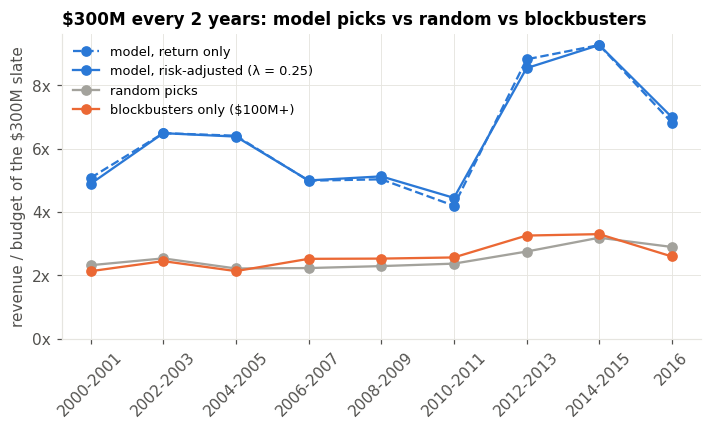

In [8]:
per_block = draws.groupby(["strategy", "block"])["multiple"]
mid, low, high = per_block.median().unstack(0), per_block.quantile(0.05).unstack(0), per_block.quantile(0.95).unstack(0)
blocks = mid.index
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for strategy, color, style, name in [("model_risk_0", BLUE, "--", "model, return only"),
                                     ("model_risk_0.25", BLUE, "-", "model, risk-adjusted (λ = 0.25)"),
                                     ("random", GRAY, "-", "random picks"),
                                     ("blockbuster", ORANGE, "-", "blockbusters only ($100M+)")]:
    ax.plot(blocks, mid[strategy], color=color, linestyle=style, marker="o", label=name)
ax.set_xticks(blocks, [f"{b}-{b + 1}" if b < 2016 else "2016" for b in blocks], rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set_ylim(0, None)
ax.set_ylabel("revenue / budget of the $300M slate")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("$300M every 2 years: model picks vs random vs blockbusters")
save(fig, "15_backtest_by_block")

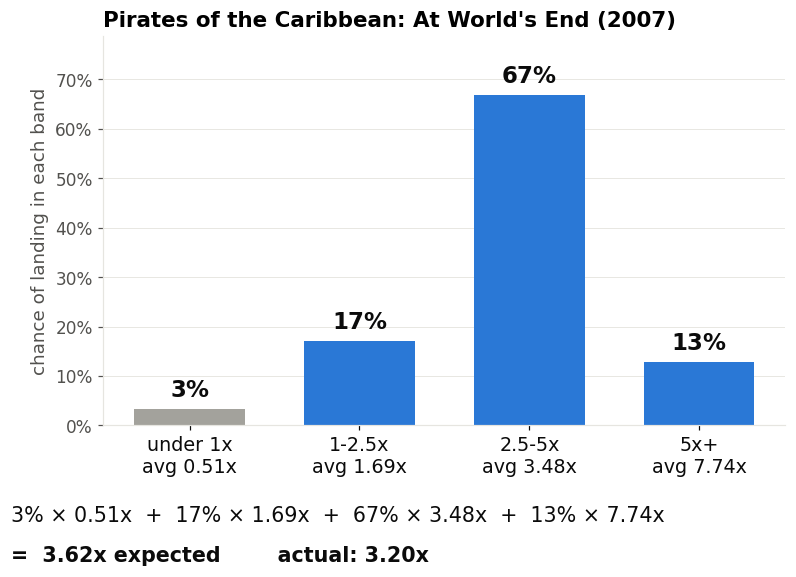

In [9]:
# worked example: how the 1x, 2.5x and 5x models combine into one expected multiple
film = pred[pred["title"] == "Pirates of the Caribbean: At World's End"].iloc[0]
p1, p2_5, p5 = film["pred"], film["pred_2.5x"], film["pred_5x"]
chances = [1 - p1, p1 - p2_5, p2_5 - p5, p5]

# band averages come from the years the model trained on, for films with a similar budget, same as in backtest.py
edges, means, _ = band_averages(d[d["year"] < film["year"] // 2 * 2])
averages = means[np.searchsorted(edges, film["budget_real"])]
expected = sum(c * m for c, m in zip(chances, averages))

bands = ["under 1x", "1-2.5x", "2.5-5x", "5x+"]
labels = [f"{b}\navg {m:.2f}x" for b, m in zip(bands, averages)]
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(labels, chances, color=[GRAY, BLUE, BLUE, BLUE], width=0.65)
for i, c in enumerate(chances):
    ax.text(i, c + 0.015, f"{c:.0%}", ha="center", va="bottom", fontsize=15, fontweight="bold", color=INK)
ax.yaxis.set_major_formatter(PCT)
ax.tick_params(axis="x", labelsize=12.5, colors=INK)
ax.tick_params(axis="y", labelsize=11)
ax.set_ylim(0, max(chances) + 0.12)
ax.grid(axis="x", visible=False)
ax.set_ylabel("chance of landing in each band", fontsize=12)
ax.set_title(f"{film['title']} ({film['year']:.0f})", fontsize=14)

# the actual sum, written out under the chart
parts = "  +  ".join(f"{c:.0%} × {m:.2f}x" for c, m in zip(chances, averages))
fig.text(0.02, -0.08, parts, fontsize=13.5, color=INK, ha="left")
fig.text(0.02, -0.16, f"=  {expected:.2f}x expected        actual: {film['roi']:.2f}x",
         fontsize=13.5, color=INK, ha="left", fontweight="bold")
save(fig, "16_three_models_example")

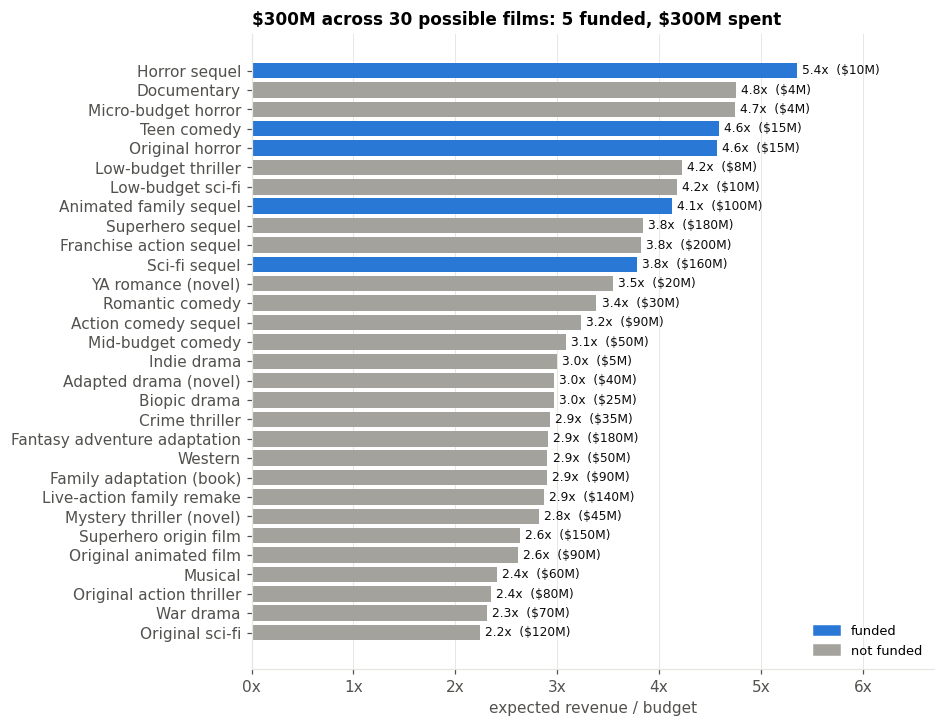

In [10]:
# the 30 made-up films for next year, and which ones the model funds with $300M
future = pd.read_csv("../data/processed/future_profiles.csv").sort_values("exp_multiple")
funded = future[future["funded"]]
fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(future["name"], future["exp_multiple"], color=np.where(future["funded"], BLUE, GRAY))
for y, (_, film) in enumerate(future.iterrows()):
    ax.text(film["exp_multiple"] + 0.05, y, f"{film['exp_multiple']:.1f}x  ({money(film['budget_real'])})",
            va="center", fontsize=8, color=INK)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set_xlim(0, future["exp_multiple"].max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_xlabel("expected revenue / budget")
ax.legend(handles=[Patch(color=BLUE, label="funded"), Patch(color=GRAY, label="not funded")], loc="lower right", fontsize=8.5)
spent = money(funded["budget_real"].sum()).replace("$", "\\$")  # two $ signs in a title turn into math text
ax.set_title(f"\\$300M across 30 possible films: {len(funded)} funded, {spent} spent")
save(fig, "17_future_slate")

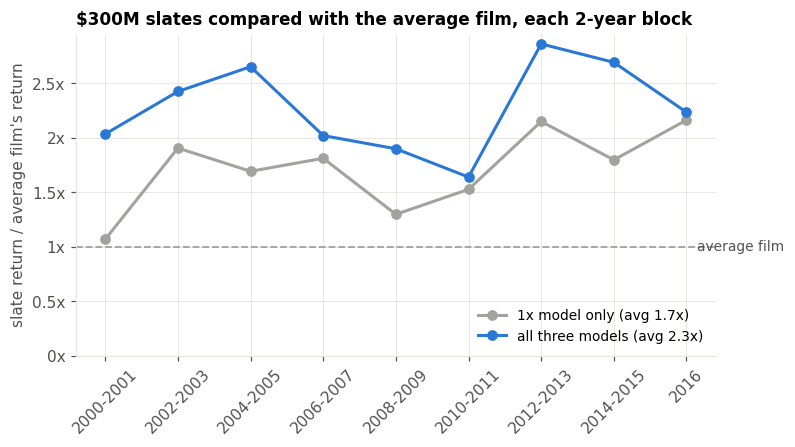

In [11]:
# $300M slates vs the market: each block's slate return / the return of every film released that block
market = pred.assign(block=(pred["year"] // 2 * 2).astype(int)).groupby("block").apply(
    lambda f: f["revenue_real"].sum() / f["budget_real"].sum())
slates = draws[draws["strategy"].isin(["1x_model_only", "model_risk_0.25"])].pivot(index="block", columns="strategy", values="multiple")
vs_market = slates.div(market, axis=0)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
blocks = vs_market.index
ax.axhline(1, color=GRAY, linestyle="--", linewidth=1.2)
ax.text(blocks[-1] + 0.3, 1, "average film", va="center", fontsize=9, color=MUTED)
for col, color, name in [("1x_model_only", GRAY, "1x model only"), ("model_risk_0.25", BLUE, "all three models")]:
    ax.plot(blocks, vs_market[col], color=color, marker="o", linewidth=2, label=f"{name} (avg {vs_market[col].mean():.1f}x)")
ax.set_xticks(blocks, [f"{b}-{b + 1}" if b < 2016 else "2016" for b in blocks], rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set_ylim(0, None)
ax.set_ylabel("slate return / average film's return")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("\\$300M slates compared with the average film, each 2-year block")
save(fig, "18_three_vs_one")

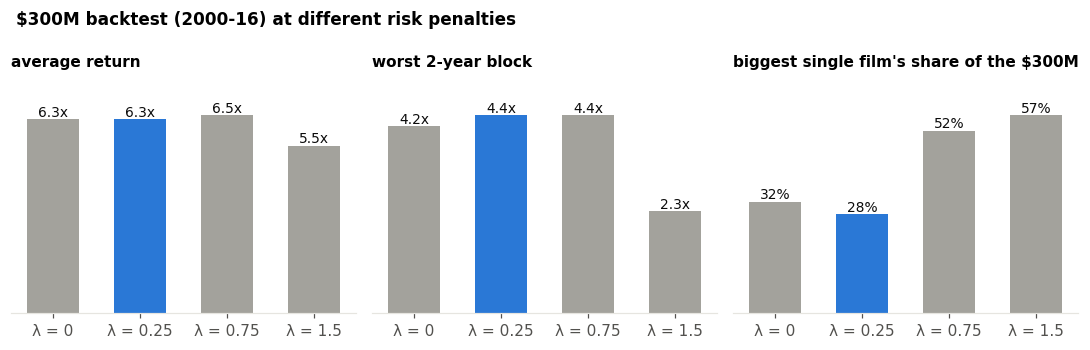

In [12]:
# the risk penalty: score = expected profit - λ x std dev of the slate. how the backtest changes with λ
summary = pd.read_csv("../data/processed/backtest_summary.csv", index_col=0)
lams = [0, 0.25, 0.75, 1.5]
rows = summary.loc[[f"model_risk_{l}" for l in lams]].copy()

# how much of each $300M slate goes into its single biggest film, averaged over the blocks
all_picks = pd.read_csv("../data/processed/backtest_model_picks.csv")
per_slate = all_picks.groupby(["penalty", "block"])["budget_real"]
biggest = (per_slate.max() / per_slate.sum()).groupby("penalty").mean()
rows["biggest_share"] = biggest.loc[lams].values
colors = [BLUE if l == 0.25 else GRAY for l in lams]
labels = [f"λ = {l}" for l in lams]
panels = [("avg_multiple", "average return", "{:.1f}x"), ("worst_multiple", "worst 2-year block", "{:.1f}x"),
          ("biggest_share", "biggest single film's share of the \\$300M", "{:.0%}")]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, (col, title, fmt) in zip(axes, panels):
    bars = ax.bar(labels, rows[col], color=colors, width=0.6)
    for bar, v in zip(bars, rows[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_title(title, fontsize=10)
    ax.set_yticks([])
    ax.grid(visible=False)
    ax.spines["left"].set_visible(False)
    ax.set_ylim(0, rows[col].max() * 1.2)
fig.suptitle("\\$300M backtest (2000-16) at different risk penalties", x=0.02, ha="left", fontweight="bold", fontsize=11)
fig.tight_layout()
save(fig, "19_risk_tradeoff")

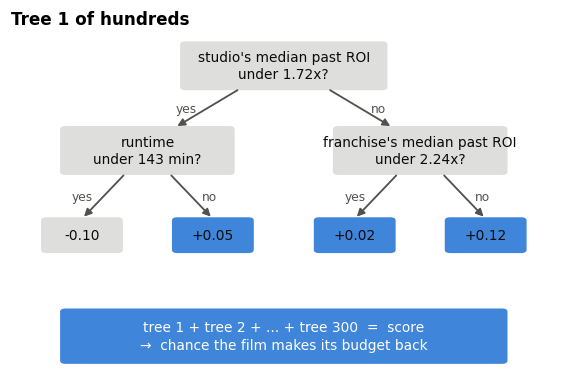

In [13]:
# how xgboost works, with a real tree. the real model's trees are deeper, so this one is from a 2-level version
import xgboost as xgb
sys.path.append("../src")
from model import BASICS, TRACK

train = d[d["year"] <= 2016]
features = BASICS + TRACK + [g for g in d.columns if g.startswith("genre_")]
small = xgb.XGBClassifier(max_depth=2, n_estimators=300, learning_rate=0.1, random_state=0)
small.fit(train[features], train["profitable"])
tree = small.get_booster().trees_to_dataframe().query("Tree == 0").set_index("ID")

names = {"studio_median_roi": "studio's median past ROI", "franchise_median_roi": "franchise's median past ROI",
         "runtime": "runtime", "log_budget": "budget"}

def question(node):
    row = tree.loc[node]
    return f"{names.get(row.Feature, row.Feature)}\nunder {row.Split:.3g}{' min' if row.Feature == 'runtime' else 'x'}?"

def box(x, y, words, color, text_color=INK, w=0.3, h=0.13):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.01",
                                facecolor=color, edgecolor="none", alpha=0.9 if color == BLUE else 0.35))
    ax.text(x, y, words, ha="center", va="center", fontsize=9, color=text_color, linespacing=1.3)

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.2))
    ax.text((x1 + x2) / 2 + (0.02 if x2 > x1 else -0.02), (y1 + y2) / 2, label, fontsize=8, color=MUTED,
            ha="left" if x2 > x1 else "right", va="center")

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0.06, 0.98)
ax.axis("off")
root, left, right = "0-0", tree.loc["0-0", "Yes"], tree.loc["0-0", "No"]
box(0.5, 0.9, question(root), GRAY, w=0.36)
box(0.25, 0.64, question(left), GRAY, w=0.42)
box(0.75, 0.64, question(right), GRAY, w=0.42)
arrow(0.42, 0.83, 0.3, 0.71, "yes")
arrow(0.58, 0.83, 0.7, 0.71, "no")
for parent, x in [(left, 0.25), (right, 0.75)]:
    for side, dx, label in [("Yes", -0.12, "yes"), ("No", 0.12, "no")]:
        value = tree.loc[tree.loc[parent, side], "Gain"]  # for a leaf, this column holds its score
        box(x + dx, 0.38, f"{value:+.2f}", BLUE if value > 0 else GRAY, w=0.13, h=0.09)
        arrow(x + dx / 3, 0.57, x + dx, 0.43, label)
ax.text(0.5, 0.28, "each tree nudges the score up (blue) or down (gray)", ha="center", fontsize=8, color=MUTED)
box(0.5, 0.15, "add up all 300 trees = score\nscore turns into the chance the film makes its budget back",
    BLUE, text_color="white", w=0.86, h=0.14)
ax.set_title("One of the model's 300 trees", loc="left")
save(fig, "20_xgboost_diagram")

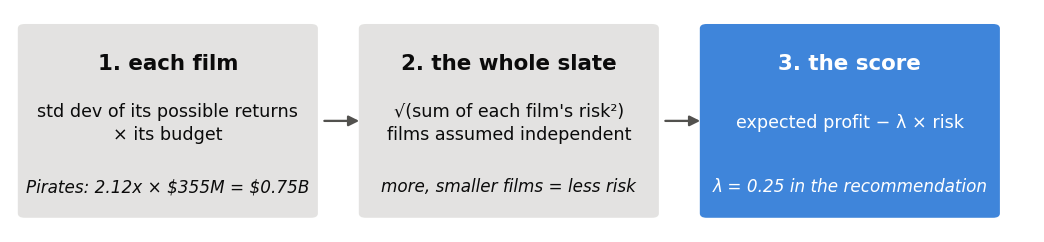

In [14]:
# how risk is worked out, with the pirates numbers worked out the same way as the backtest
film = pred[pred["title"] == "Pirates of the Caribbean: At World's End"]
pirates = profit_and_risk(film, d[d["year"] < film["year"].iloc[0] // 2 * 2]).iloc[0]
sd = pirates["sd_profit"] / pirates["budget_real"]
example = f"Pirates: {sd:.2f}x × \\${pirates['budget_real'] / 1e6:.0f}M = \\${pirates['sd_profit'] / 1e9:.2f}B"

steps = [("1. each film", "std dev of its possible returns\n× its budget", example),
         ("2. the whole slate", "√(sum of each film's risk²)\nfilms assumed independent", "more, smaller films = less risk"),
         ("3. the score", "expected profit − λ × risk", "λ = 0.25 in the recommendation")]
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)
ax.axis("off")
for i, (head, how, example) in enumerate(steps):
    last = i == len(steps) - 1
    ax.add_patch(FancyBboxPatch((i + 0.04, 0.08), 0.84, 0.84, boxstyle="round,pad=0.02",
                                facecolor=BLUE if last else GRAY, edgecolor="none", alpha=0.9 if last else 0.3))
    color = "white" if last else INK
    ax.text(i + 0.46, 0.76, head, ha="center", va="center", fontsize=14, fontweight="bold", color=color)
    ax.text(i + 0.46, 0.49, how, ha="center", va="center", fontsize=11.5, color=color, linespacing=1.4)
    ax.text(i + 0.46, 0.2, example, ha="center", va="center", fontsize=11, style="italic", color=color)
    if not last:
        ax.annotate("", xy=(i + 1.03, 0.5), xytext=(i + 0.91, 0.5),
                    arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.5, mutation_scale=14))
save(fig, "21_risk_calc")